In [ ]:
from google.colab import files

print("Please select your three CSV files to upload:")
uploaded = files.upload()

import os
print("\nFiles currently in Colab:")
print(os.listdir())

Please select your three CSV files to upload:


Saving security_high_moderation_timings_plusControls.csv to security_high_moderation_timings_plusControls (1).csv
Saving moderation_timings_data_community.csv to moderation_timings_data_community (1).csv
Saving baseline_results.csv to baseline_results (1).csv

Files currently in Colab:
['.config', 'baseline_results (1).csv', 'security_high_moderation_timings_plusControls (1).csv', 'security_high_moderation_timings_plusControls.csv', 'moderation_timings_data_community.csv', 'moderation_timings_data_community (1).csv', 'baseline_results.csv', 'sample_data']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sec_df = pd.read_csv("security_high_moderation_timings_plusControls.csv")
mod_df = pd.read_csv("moderation_timings_data_community.csv")
base_df = pd.read_csv("baseline_results.csv")

print("Files loaded successfully!")

Files loaded successfully!


In [ ]:
base_df = base_df[base_df['browser'] == 'Google Chrome'].copy()

base_df.rename(columns={'text_type': 'text_length'}, inplace=True)

base_df['tos_breach'] = 'control'

base_df.drop(columns=['browser'], inplace=True)

combined_df = pd.concat([sec_df, mod_df, base_df], ignore_index=True)

post_times = combined_df[combined_df['condition'] == 'baseline_text_post'].copy()
mod_times = combined_df[combined_df['condition'] == 'heuristics_only_moderation'].copy()

post_times['Group'] = np.where(post_times['tos_breach'] == 'control', 'Control (No ToS Breach)', 'Moderated (ToS Breach)')
mod_times['Group'] = np.where(mod_times['tos_breach'] == 'control', 'Control (No ToS Breach)', 'Moderated (ToS Breach)')

print("Data cleaned and combined! Total rows:", len(combined_df))

Data cleaned and combined! Total rows: 171


In [ ]:
recap_post = post_times.groupby('Group')['post_ms'].agg(['mean', 'median', 'std', 'count']).round(2)
recap_mod = mod_times.groupby('Group')['moderation_event_ms'].agg(['mean', 'median', 'std', 'count']).round(2)

recap_table = pd.concat([recap_post, recap_mod], keys=['Post Time (ms)', 'Moderation Time (ms)'])

print("--- Recap Table: Control vs Moderated ---")
display(recap_table)

--- Recap Table: Control vs Moderated ---


mean  median    std  count
                     Group                                               
Post Time (ms)       Control (No ToS Breach)  80.78   72.50  22.63     18
                     Moderated (ToS Breach)   96.28   82.50  34.12     72
Moderation Time (ms) Control (No ToS Breach)   0.00    0.00   0.00      9
                     Moderated (ToS Breach)   74.66   69.45  21.62     72

In [ ]:
summary_by_group_length = post_times.groupby(["Group", "text_length"])[["post_ms"]].agg(
    ["mean", "median", "std", "min", "max"]
).round(2)

display(summary_by_group_length)

post_ms                           
                                       mean median    std   min    max
Group                   text_length                                   
Control (No ToS Breach) Long          96.33   95.0  33.66  56.0  131.0
                        Medium        71.50   70.5   5.01  67.0   80.0
                        Short         74.50   75.5  11.93  54.0   90.0
Moderated (ToS Breach)  Long         102.54   86.0  36.58  60.0  201.0
                        Medium        94.58   80.5  35.42  50.0  178.0
                        Short         91.71   83.5  30.59  47.0  157.0

In [ ]:
print("Security Columns:", sec_df.columns.tolist())
print("Social Columns:", mod_df.columns.tolist())

Security Columns: ['tos_breach', 'text_length', 'position', 'condition', 'post_ms', 'total_ms', 'moderation_event_ms', 'submit_scan_ms', 'watcher_scan_count', 'watcher_scan_ms_avg', 'watcher_scan_ms_total']
Social Columns: ['tos_breach', 'text_length', 'position', 'condition', 'post_ms', 'total_ms', 'moderation_event_ms', 'submit_scan_ms', 'watcher_scan_count', 'watcher_scan_ms_avg', 'watcher_scan_ms_total']


In [ ]:
print(post_times.columns.tolist())

['tos_breach', 'text_length', 'position', 'condition', 'post_ms', 'total_ms', 'moderation_event_ms', 'submit_scan_ms', 'watcher_scan_count', 'watcher_scan_ms_avg', 'watcher_scan_ms_total', 'Group']


In [ ]:
import pandas as pd
import numpy as np

sec_df['Scenario_Type'] = 'Security Moderation'
mod_df['Scenario_Type'] = 'Social Moderation'

base_df.rename(columns={'text_type': 'text_length'}, inplace=True)
base_df['tos_breach'] = 'control'
base_df['Scenario_Type'] = 'Baseline (Control)'
base_df.drop(columns=['browser'], inplace=True, errors='ignore')

combined_df = pd.concat([sec_df, mod_df, base_df], ignore_index=True)

post_times = combined_df[combined_df['condition'] == 'baseline_text_post'].copy()

post_times['Group'] = np.where(post_times['tos_breach'] == 'control',
                               'Control (No ToS Breach)',
                               'Moderated (ToS Breach)')

master_summary = post_times.groupby(["Scenario_Type", "Group", "text_length"])[["post_ms"]].agg(
    ["mean", "median", "std", "min", "max"]
).round(2)

display(master_summary)

post_ms                \
                                                           mean median    std   
Scenario_Type       Group                   text_length                         
Baseline (Control)  Control (No ToS Breach) Long          85.67   71.0  39.12   
                                            Medium        73.00   72.0   6.56   
                                            Short         77.00   78.0   3.61   
Security Moderation Control (No ToS Breach) Long         107.00  118.0  31.00   
                                            Medium        70.00   69.0   3.61   
                                            Short         72.00   72.0  18.00   
                    Moderated (ToS Breach)  Long         100.42   80.0  43.57   
                                            Medium       109.25  109.5  38.38   
                                            Short         88.42   77.0  32.02   
Social Moderation   Moderated (ToS Breach)  Long         104.67   91.5  29.83   
                                            Medium        79.92   72.5  26.09   
                                            Short         95.00   87.0  30.13   

                                                                      
                                                          min    max  
Scenario_Type       Group                   text_length               
Baseline (Control)  Control (No ToS Breach) Long         56.0  130.0  
                                            Medium       67.0   80.0  
                                            Short        73.0   80.0  
Security Moderation Control (No ToS Breach) Long         72.0  131.0  
                                            Medium       67.0   74.0  
                                            Short        54.0   90.0  
                    Moderated (ToS Breach)  Long         60.0  201.0  
                                            Medium       50.0  178.0  
                                            Short        47.0  137.0  
Social Moderation   Moderated (ToS Breach)  Long         71.0  147.0  
                                            Medium       52.0  140.0  
                                            Short        65.0  157.0

In [ ]:
import pandas as pd

moderation_metrics = [
    "moderation_event_ms",
    "submit_scan_ms",
    "watcher_scan_count",
    "watcher_scan_ms_avg",
    "watcher_scan_ms_total"
]

for col in moderation_metrics:
    mod_times[col] = pd.to_numeric(mod_times[col], errors='coerce')

moderated_only = mod_times[mod_times['Group'] == 'Moderated (ToS Breach)']

moderation_overall_summary = moderated_only[moderation_metrics].agg(
    ["mean", "median", "std", "min", "max"]
).T.round(2)

moderation_overall_summary.index.name = "Moderation Metric"

display(moderation_overall_summary)

,mean,median,std,min,max
Moderation Metric,,,,,
moderation_event_ms,74.66,69.45,21.62,47.9,159.1
submit_scan_ms,0.26,0.10,0.28,0.0,0.9
watcher_scan_count,1.00,1.00,0.00,1.0,1.0
watcher_scan_ms_avg,0.53,0.20,0.61,0.0,2.9
watcher_scan_ms_total,0.53,0.20,0.61,0.0,2.9


/tmp/ipykernel_19889/2961692688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Event', y='Time (ms)', data=plot_data, palette="muted")


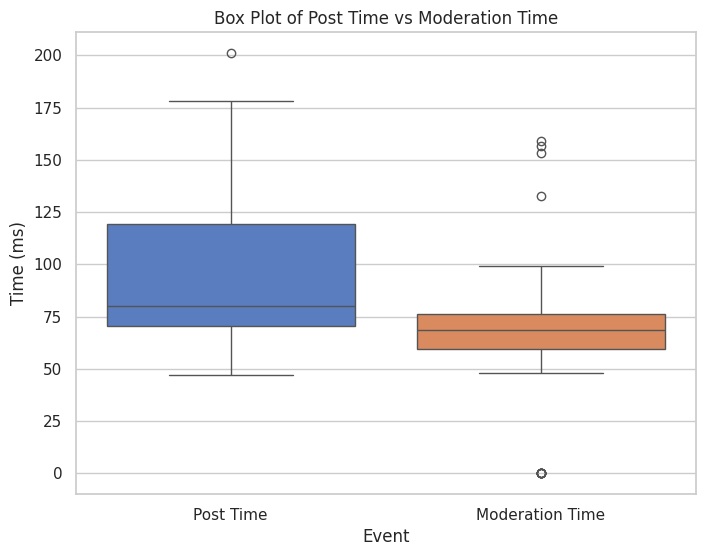

In [ ]:
plt.figure(figsize=(8, 6))
plot_data = pd.DataFrame({
    'Time (ms)': pd.concat([post_times['post_ms'].dropna(), mod_times['moderation_event_ms'].dropna()]),
    'Event': ['Post Time'] * post_times['post_ms'].dropna().shape[0] + ['Moderation Time'] * mod_times['moderation_event_ms'].dropna().shape[0]
})
sns.boxplot(x='Event', y='Time (ms)', data=plot_data, palette="muted")
plt.title('Box Plot of Post Time vs Moderation Time')
plt.show()

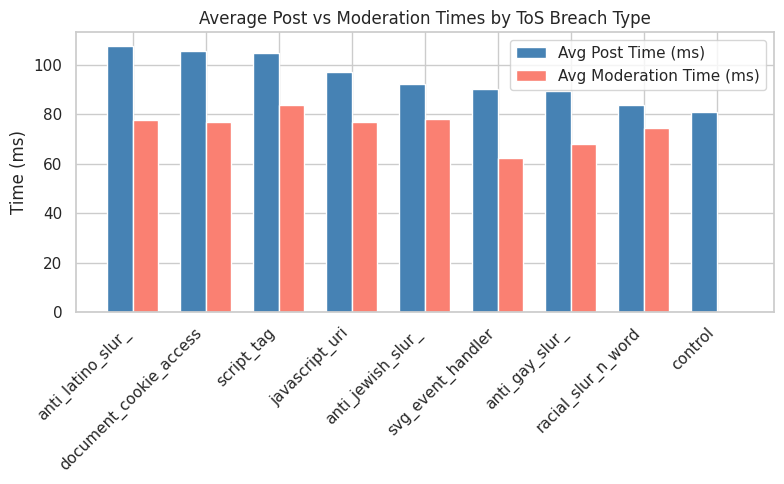

In [ ]:

post_avg = post_times.groupby('tos_breach')['post_ms'].mean().reset_index()
mod_avg = mod_times.groupby('tos_breach')['moderation_event_ms'].mean().reset_index()

avg_times = pd.merge(post_avg, mod_avg, on='tos_breach', how='outer').fillna(0)
avg_times = avg_times.sort_values(by='post_ms', ascending=False)

plt.figure(figsize=(8,5))
x = np.arange(len(avg_times))
width = 0.35

plt.bar(x - width/2, avg_times['post_ms'], width, label='Avg Post Time (ms)', color='steelblue')
plt.bar(x + width/2, avg_times['moderation_event_ms'], width, label='Avg Moderation Time (ms)', color='salmon')

plt.xticks(x, avg_times['tos_breach'], rotation=45, ha='right')
plt.ylabel('Time (ms)')
plt.title('Average Post vs Moderation Times by ToS Breach Type')
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_19889/3244553824.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mod_events, x='text_length', y='moderation_event_ms', order=length_order, palette='muted')


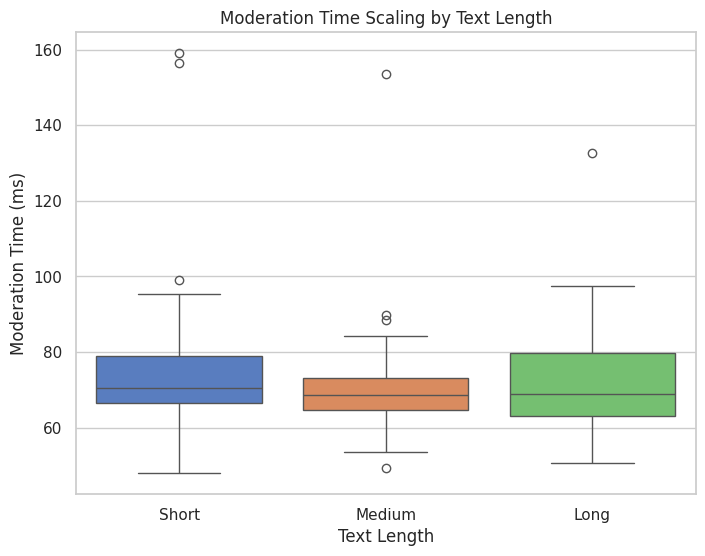

In [ ]:
mod_events = mod_times[mod_times['tos_breach'] != 'control'].copy()

plt.figure(figsize=(8, 6))

length_order = ['Short', 'Medium', 'Long']
sns.boxplot(data=mod_events, x='text_length', y='moderation_event_ms', order=length_order, palette='muted')
plt.title('Moderation Time Scaling by Text Length')
plt.xlabel('Text Length')
plt.ylabel('Moderation Time (ms)')
plt.show()

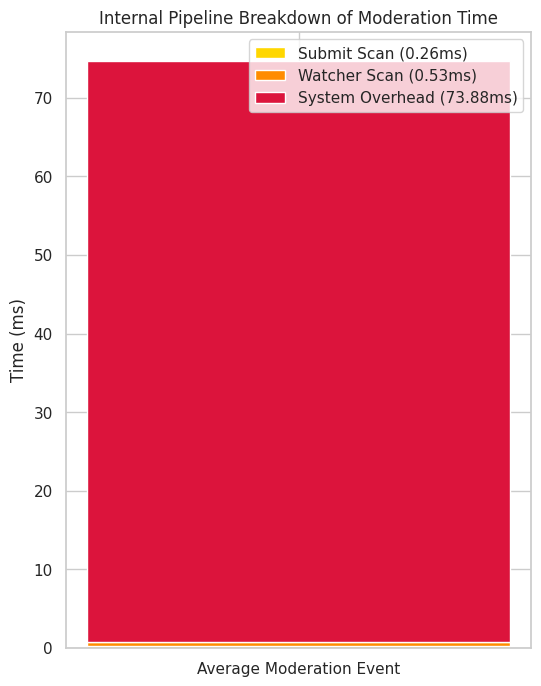

In [ ]:
mod_events['overhead_ms'] = mod_events['moderation_event_ms'] - (mod_events['submit_scan_ms'] + mod_events['watcher_scan_ms_total'])

avg_submit = mod_events['submit_scan_ms'].mean()
avg_watcher = mod_events['watcher_scan_ms_total'].mean()
avg_overhead = mod_events['overhead_ms'].mean()

plt.figure(figsize=(6, 8))
plt.bar(['Average Moderation Event'], [avg_submit], label=f'Submit Scan ({avg_submit:.2f}ms)', color='gold')
plt.bar(['Average Moderation Event'], [avg_watcher], bottom=[avg_submit], label=f'Watcher Scan ({avg_watcher:.2f}ms)', color='darkorange')
plt.bar(['Average Moderation Event'], [avg_overhead], bottom=[avg_submit + avg_watcher], label=f'System Overhead ({avg_overhead:.2f}ms)', color='crimson')

plt.ylabel('Time (ms)')
plt.title('Internal Pipeline Breakdown of Moderation Time')
plt.legend()
plt.show()

In [ ]:
length_order = ['Short', 'Medium', 'Long']
position_order = ['start', 'middle', 'end']

mod_events = mod_times[mod_times['tos_breach'] != 'control'].copy()

sns.set_theme(style="whitegrid")

/tmp/ipykernel_19889/908935512.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mod_events, x='text_length', y='moderation_event_ms', order=length_order, palette='muted')


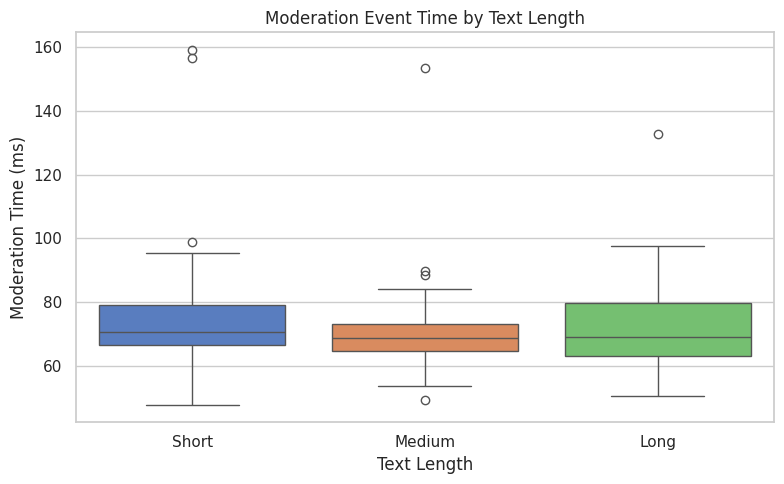

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=mod_events, x='text_length', y='moderation_event_ms', order=length_order, palette='muted')
plt.title('Moderation Event Time by Text Length')
plt.xlabel('Text Length')
plt.ylabel('Moderation Time (ms)')
plt.tight_layout()
plt.show()

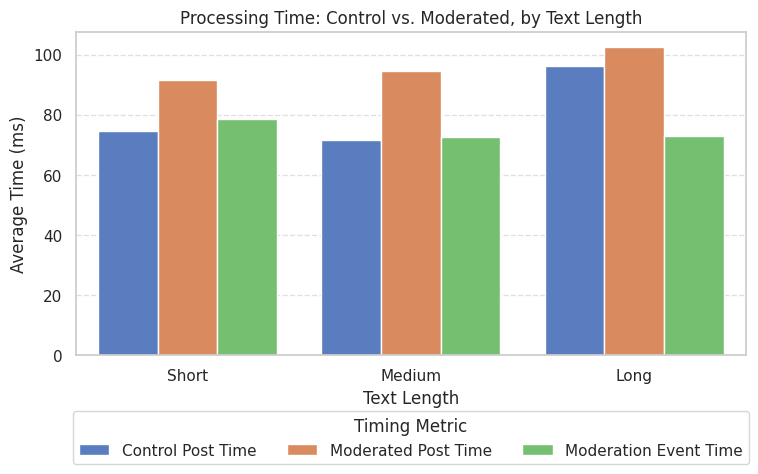

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


control_avg = post_times[post_times['Group'] == 'Control (No ToS Breach)'].groupby('text_length')['post_ms'].mean().reset_index()
control_avg.rename(columns={'post_ms': 'Time (ms)'}, inplace=True)
control_avg['Metric'] = 'Control Post Time'

mod_post_avg = post_times[post_times['Group'] == 'Moderated (ToS Breach)'].groupby('text_length')['post_ms'].mean().reset_index()
mod_post_avg.rename(columns={'post_ms': 'Time (ms)'}, inplace=True)
mod_post_avg['Metric'] = 'Moderated Post Time'

mod_event_avg = mod_times[mod_times['Group'] == 'Moderated (ToS Breach)'].groupby('text_length')['moderation_event_ms'].mean().reset_index()
mod_event_avg.rename(columns={'moderation_event_ms': 'Time (ms)'}, inplace=True)
mod_event_avg['Metric'] = 'Moderation Event Time'

compare_df = pd.concat([control_avg, mod_post_avg, mod_event_avg])

plt.figure(figsize=(8, 5))

sns.barplot(
    data=compare_df,
    x='text_length',
    y='Time (ms)',
    hue='Metric',
    order=length_order,
    palette='muted'
)

plt.title('Processing Time: Control vs. Moderated, by Text Length')
plt.xlabel('Text Length')
plt.ylabel('Average Time (ms)')

plt.legend(title='Timing Metric', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_19889/1772477945.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mod_events, x='position', y='moderation_event_ms', order=position_order, palette='muted')


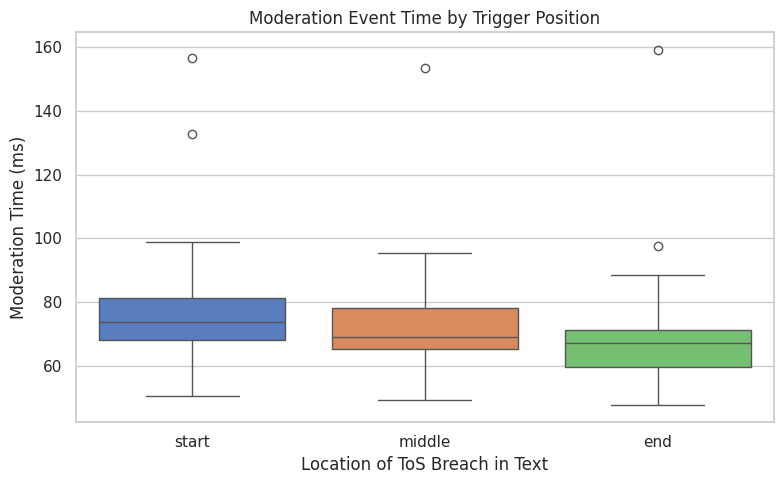

In [ ]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=mod_events, x='position', y='moderation_event_ms', order=position_order, palette='muted')
plt.title('Moderation Event Time by Trigger Position')
plt.xlabel('Location of ToS Breach in Text')
plt.ylabel('Moderation Time (ms)')
plt.tight_layout()
plt.show()

In [ ]:

base_controls = len(base_df)
sec_controls = len(sec_df[sec_df['tos_breach'] == 'control'])
mod_controls = len(mod_df[mod_df['tos_breach'] == 'control']) if 'control' in mod_df['tos_breach'].values else 0

total_controls = base_controls + sec_controls + mod_controls

sec_mod = len(sec_df[sec_df['tos_breach'] != 'control'])
mod_mod = len(mod_df[mod_df['tos_breach'] != 'control'])

total_mod = sec_mod + mod_mod

total_data_points = total_controls + total_mod

print("--- Dataset Composition ---")
print(f"Total data points analyzed: {total_data_points}")
print(f"Total control values:       {total_controls}")
print(f"Total moderation values:    {total_mod}")
print(f"  --> Security Scenarios:   {sec_mod}")
print(f"  --> Social Scenarios:     {mod_mod}")

--- Dataset Composition ---
Total data points analyzed: 171
Total control values:       27
Total moderation values:    144
  --> Security Scenarios:   72
  --> Social Scenarios:     72
